# Lab #7/8: Tidal Aliasing
### Farhan Ariff bin Halis Azhan
### Collaborators
* Name
* Name

## Goal and Introduction
The goal of this lab is to analyze alias in tidal patterns.  
Aliasing happened when the sampling rate of the fft are larger than the real sampling rate of data collection.  
The data set has time delta of one hour for each data taken, and its duration is only one month.   
In a sense, the dataset given are already undersampled, as tidal patterns will take more than one month of sampling of data to make analyzing it effective.  

## Data
The dataset what will be used in this lab is noaa_slh.nc. From this dataset, we will use two variables which are the datetime the data was taken, the height of water level (in meters).
The difference between the time the data was taken are one hour each.

----

## Approach and Results
Describe your approach for each question in the lab description and interpretation of the results for that question.
Start with an over-arching paragraph to describe your approach as you see fit.

In [118]:
# Import critical libraries:
import numpy as np
import matplotlib.pyplot as plt
from  matplotlib.dates import num2date
from scipy.ndimage import uniform_filter1d
from scipy.io import netcdf_file
from scipy.fftpack import fft, fftfreq, ifft

plt.style.use('ggplot')

### Question 1
First of all, we will read the noaa_slh.nc file, and load it into variable data. This file contain hourly measurements of the sea level at _____ from ____ to ____, for a duration of one whole month.
When analyzing the data variable, we will also determine its available variable and the units correspondin to the variables.

In [82]:
# Open the file in read mode
data = netcdf_file('noaa_slh.nc', "r")

# Print off the file-level attribute, "info"
print(data.header)

# Get a list of dimensions and variables:
print(data.dimensions.keys())
print(data.variables.keys())

# Get the number of points in dimension "time":
print(data.dimensions['time'])

b'\nNOAA National Ocean Service - Center for Operational Oceanographic Products and Services\nData Archive <http   co-ops.nos.noaa.gov data_res.html>\n\nVerified Hourly Water Level Data (W2)\nData are in Meters above MSL\nTimes are on UTC (GMT).\n'
dict_keys(['time'])
dict_keys(['time', 'height', 'sigma'])
624


/tmp/ipykernel_443/3625985928.py:2: RuntimeWarning: Cannot close a netcdf_file opened with mmap=True, when netcdf_variables or arrays referring to its data still exist. All data arrays obtained from such files refer directly to data on disk, and must be copied before the file can be cleanly closed. (See netcdf_file docstring for more information on mmap.)
  data = netcdf_file('noaa_slh.nc', "r")


Below, we are exploring the data variable (the .sc file), and see what attribute, dimensions and variables in this variable.

In [83]:
# Extract the values associated with the variables "heights" and its units
print(data.variables['height'].info)
print(data.variables['height'].units)
heights = data.variables['height'][:]

b'Water level height above mean sea level (MSL).'
b'meters'


In [84]:
# Extract the values associated with the variables "times" and its units
print(data.variables["time"].info)
print(data.variables['time'].units)
times = data.variables['time'][:]
times = num2date(times)

b'Time in days from 1970-01-01T00:00:00. Use matplotlib.dates.num2date to convert to datetimes.'
b'Days'


In [85]:
# print(data._attributes)
print(data._attributes["header"])
print(data._attributes["history"])
print(data._attributes["station_info"])
print(data._attributes["station_number"])

b'\nNOAA National Ocean Service - Center for Operational Oceanographic Products and Services\nData Archive <http   co-ops.nos.noaa.gov data_res.html>\n\nVerified Hourly Water Level Data (W2)\nData are in Meters above MSL\nTimes are on UTC (GMT).\n'
b'March 2024: Initial version created by DTW for Earth/Space 323.'
b'HONOLULU, HONOLULU HARBOR, OAHU ISLAND ,HI  from  20050106 to 20050131'
1612340


Now, we will plot sea level height against time.

Text(0, 0.5, 'Sea Level Height (in meters above MSL)')

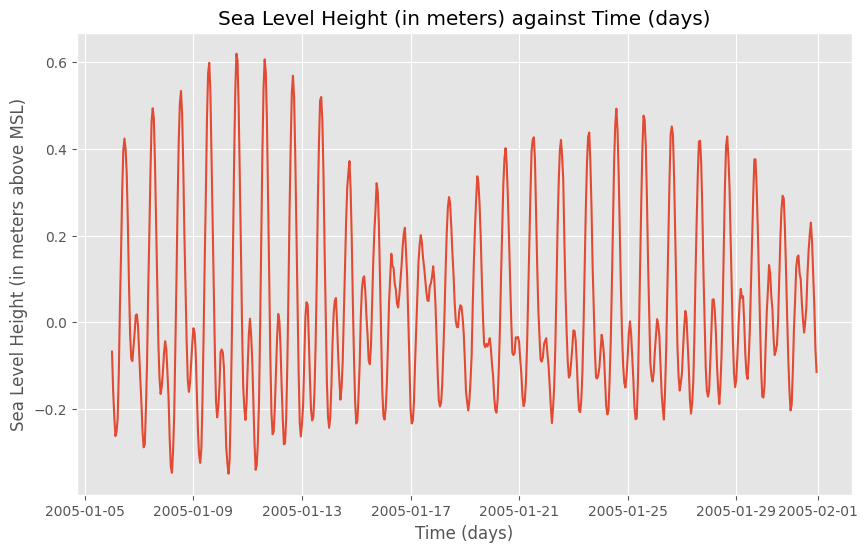

In [86]:
# Create a plot of 
fig = plt.figure(figsize=(10,6))
ax1 = fig.subplots(1,1)

ax1.plot(times, heights)
# setting the title, x label and y label
ax1.set_title(f'Sea Level Height (in meters) against Time (days)')
ax1.set_xlabel(f'Time (days)')
ax1.set_ylabel(f'Sea Level Height (in meters above MSL)')

From data exploration, we can found out that:
- This data was taken from Honolulu, Honolulu Harbor, Oahu Isaland, Hi,
- The time period of the dataset is One whole month.
- The variable that correspond to sea level height is "height" and its unit is in meters.
- The sea level height seems to be in the minimum in the middle of the month, while seems highest in week 1 and week 3. I assume this happen because moon's distance to the earth differed in these months.
- The sampling freqeuncy is one sample per hour, and the most important period of the set is from fifth January to 17th January and 17th January to 1st February.

### Question 2
Now we will conduct FFT on the whole data.

In [87]:
# length of time series
N = heights.size 
dtDay = 1.0/24
# get fast fourier transform of the dataset
data_freq = fft(heights)

# get frequency associated with the FT
freqsfft = fftfreq(N, dtDay)

Then, we plot the amplitude spectrum agains frequencies in units of cycles/day

Text(0, 0.5, 'Amplitude (meters)')

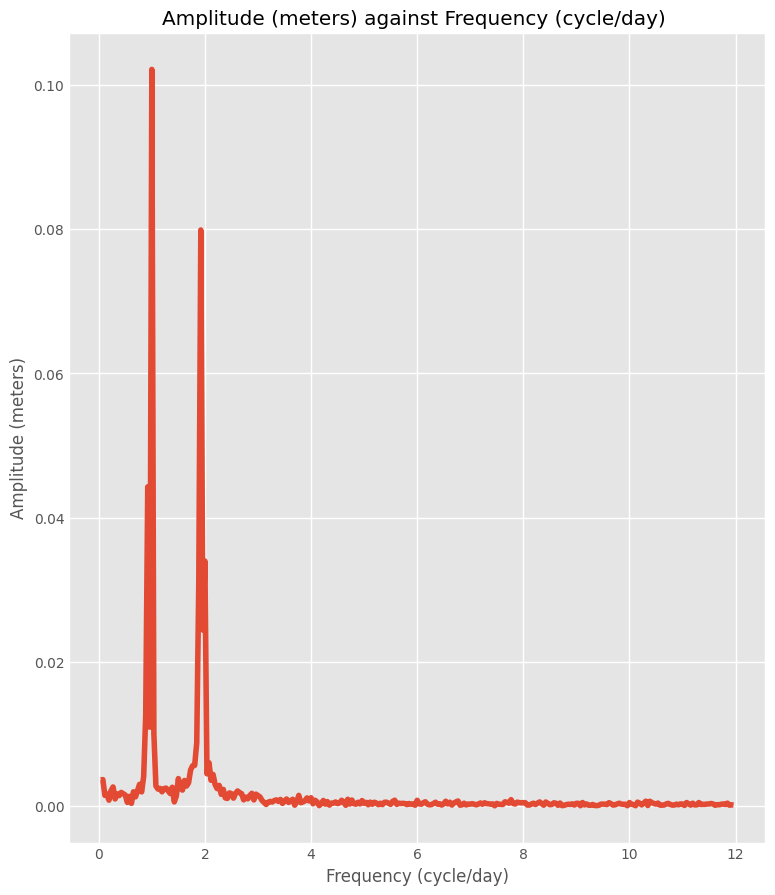

In [121]:
# Make a figure of the power spectrum for flux against frequency
fig = plt.figure(figsize=(8, 10))
axe = plt.subplot(111)

data_freq_abs = np.abs(data_freq[1:N//2]) / N
# Plot the power against frequency
axe.plot(freqsfft[1:N//2], data_freq_abs)

# give title, xlabel, ylabel into axis 
axe.set_title(f'Amplitude (meters) against Frequency (cycle/day) ')
axe.set_xlabel(f'Frequency (cycle/day)')
axe.set_ylabel(f'Amplitude (meters)')

In [89]:
# The index for the largest power
largest_pow_index = np.argmax(data_freq_abs)
print(f"The index for the largest amplitude is : {largest_pow_index}")
print(f"The frequency for the largest power is {freqsfft[largest_pow_index]}")
print(f"The corresponding period for the frequency is {1.0/freqsfft[largest_pow_index]}")

The index for the largest amplitude is : 25
The frequency for the largest power is 0.9615384615384616
The corresponding period for the frequency is 1.04


The maximum frequency is the Nyquist frequency, which is half the sampling frequency. In other words, for this data, the maximum frequency that can accurately represent the signal is 6 cycle/day.

The period associated with the largest amplitude is 1.04 days per cycle

### Question 3
Now we will filter the the frequency above to zero out the frequency component that is higher than 0.5 cycles/day.

In [90]:
import copy 
filter = np.abs(freqsfft) > 0.5
data_freq_1pf = copy.deepcopy(data_freq)
data_freq_1pf[filter] = 0
# print(data_freq_1pf)

Then, we will plot this filtered out data against time, over the original data (the one without filtering).

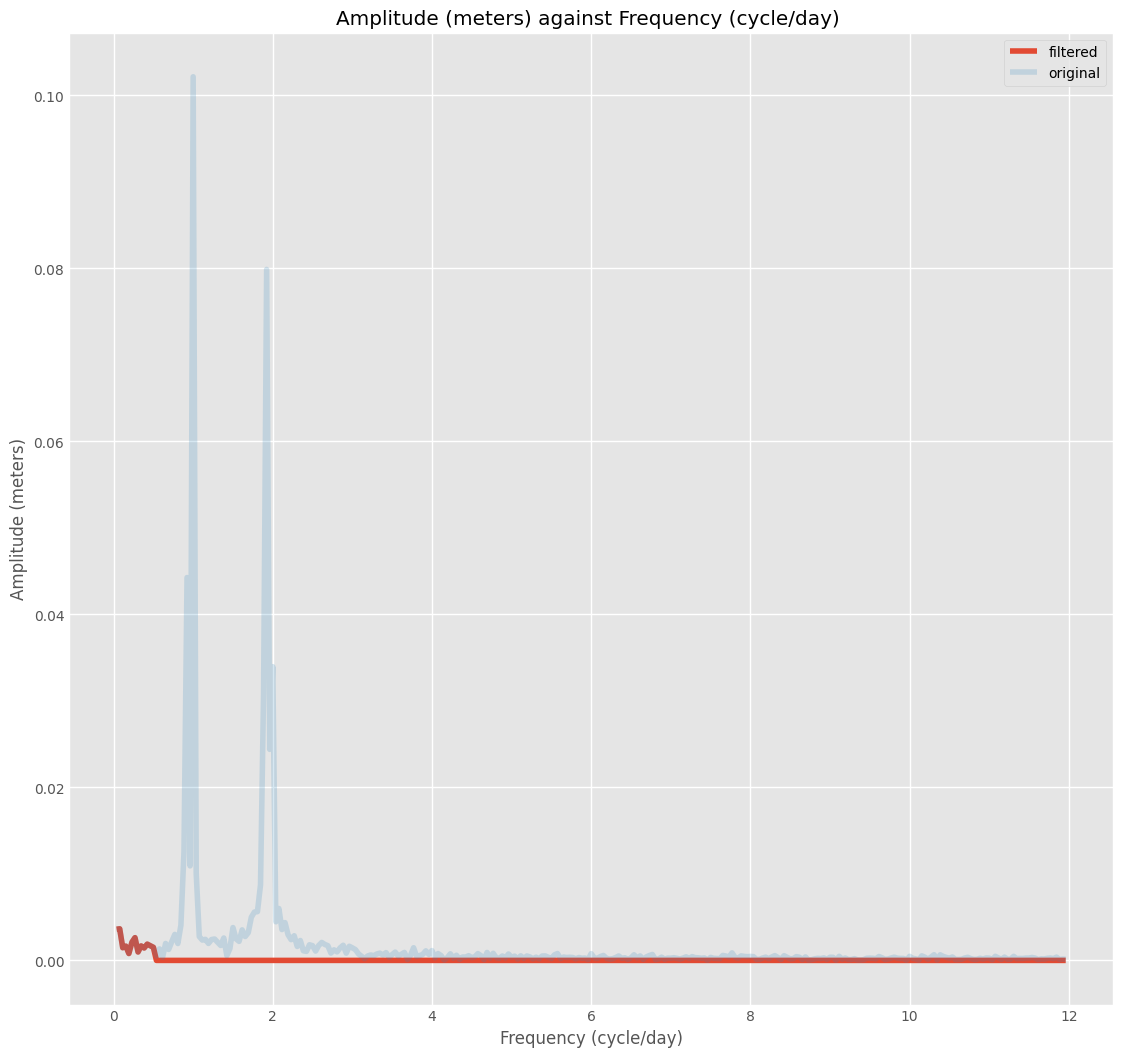

In [122]:
# Make a figure of the power spectrum for flux against frequency
fig = plt.figure(figsize=(12, 12))
ax3 = plt.subplot(111)

# Plot the power against frequency
ax3.plot(freqsfft[1:N//2], np.abs(data_freq_1pf[1:N//2]) / N, label = f"filtered")
ax3.plot(freqsfft[1:N//2], np.abs(data_freq[1:N//2]) / N, label = f"original", alpha = 0.2 )
# axe.plot(freqsfft[1:N//2], np.abs(data_ft[1:N//2]), 'o')

# give title, xlabel, ylabel into axis 
ax3.set_title(f'Amplitude (meters) against Frequency (cycle/day) ')
ax3.set_xlabel(f'Frequency (cycle/day)')
ax3.set_ylabel(f'Amplitude (meters)')

ax3.legend()

Then we will use the ifft function to convert the filtered data from frequency domain to time domain. Consequently, we will plot the result against the time.

/home/farharif/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/farharif/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


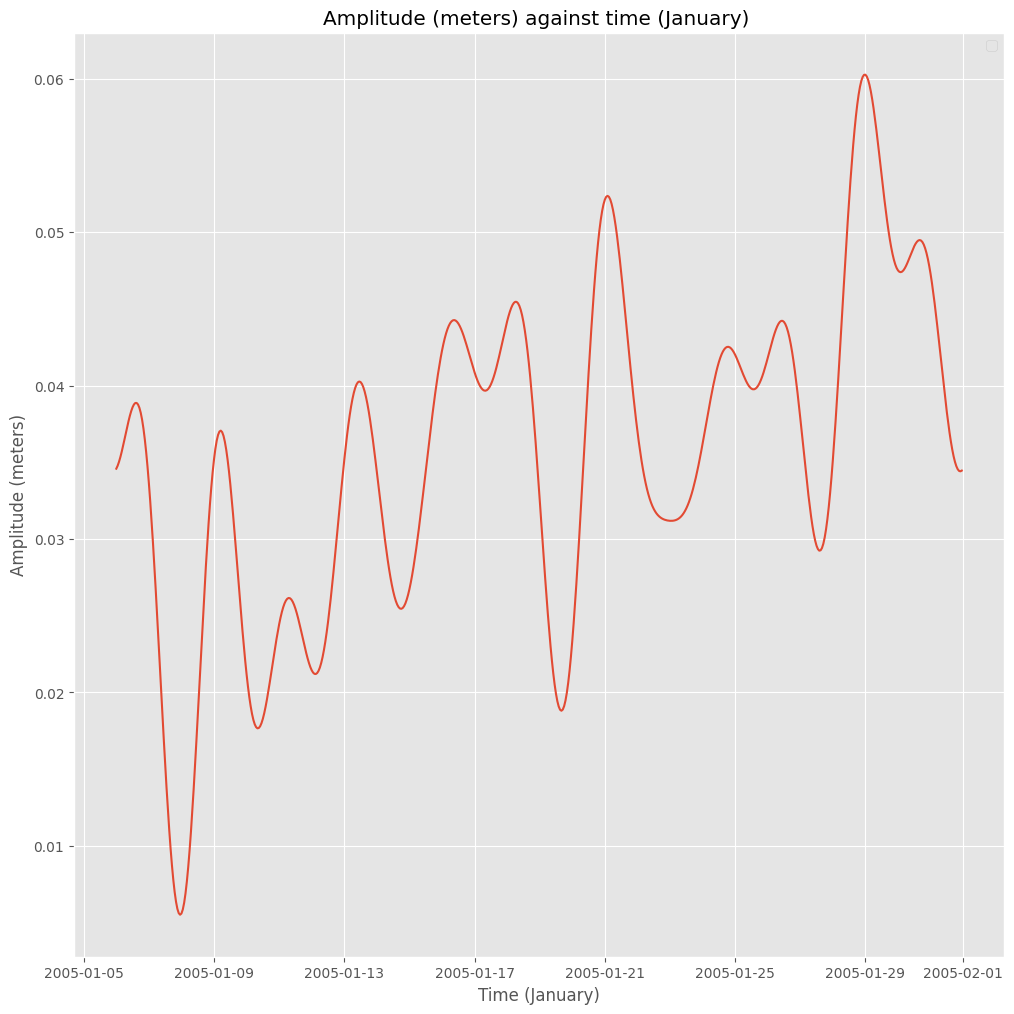

In [92]:
data_time_1pf = ifft(data_freq_1pf)

# Make a figure of the power spectrum for flux against frequency
fig = plt.figure(figsize=(12, 12))
ax32 = plt.subplot(111)

# Plot the power against frequency
ax32.plot(times, data_time_1pf, label = "gold standard")
# give title, xlabel, ylabel into axis 
ax32.set_title(f'Amplitude (meters) against time (January) ')
ax32.set_xlabel(f'Time (January)')
ax32.set_ylabel(f'Amplitude (meters)')

ax32.legend()

The water level will tend to flucutate to highest or lowest every 1 day.

### Question 4
Now, instead of filtering in frequency domain like what we do in previous question, we will filter the data in time domain. We will filter in time domain by doing a 2-day running average on the data variable using uniform_filter1d function that we used from previous lab.

In [93]:
data_time_2avg = data_filter = uniform_filter1d(heights, size = 48)
# print(data_time_2avg)

Then we will plot this filtered data (wrt to time domain) against time.

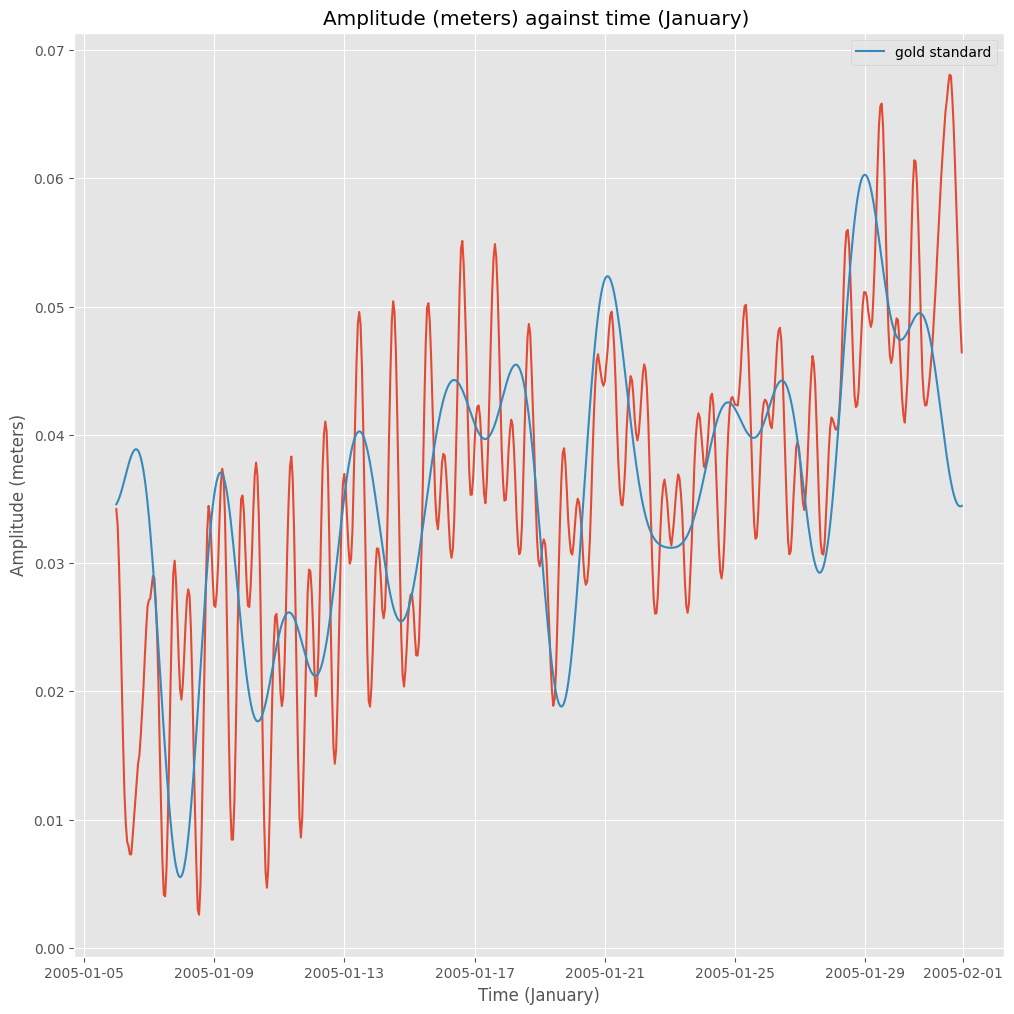

In [94]:
# Make a figure of the power spectrum for flux against frequency
fig = plt.figure(figsize=(12, 12))
ax4 = plt.subplot(111)

# Plot the power against frequency
ax4.plot(times, data_time_2avg, label = 'filetered 2 days average')
ax4.plot(times, data_time_1pf, label = "gold standard")
# give title, xlabel, ylabel into axis 
ax4.set_title(f'Amplitude (meters) against time (January) ')
ax4.set_xlabel(f'Time (January)')
ax4.set_ylabel(f'Amplitude (meters)')

ax4.legend()

To perform 2-days running average, we must averaged together 48 samples, as each sample was taken every hour, to a total of 48 hours.

The trend found in data_time_2avg seems almost similar to q3's trend.

### Question 5
Now we will perform fft on the 2-days running average we did in previous question, and then plot it against frequency, with x-axis limited to a range of 0 to 1.  

In [95]:
data_freq_2avg = fft(data_time_2avg)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


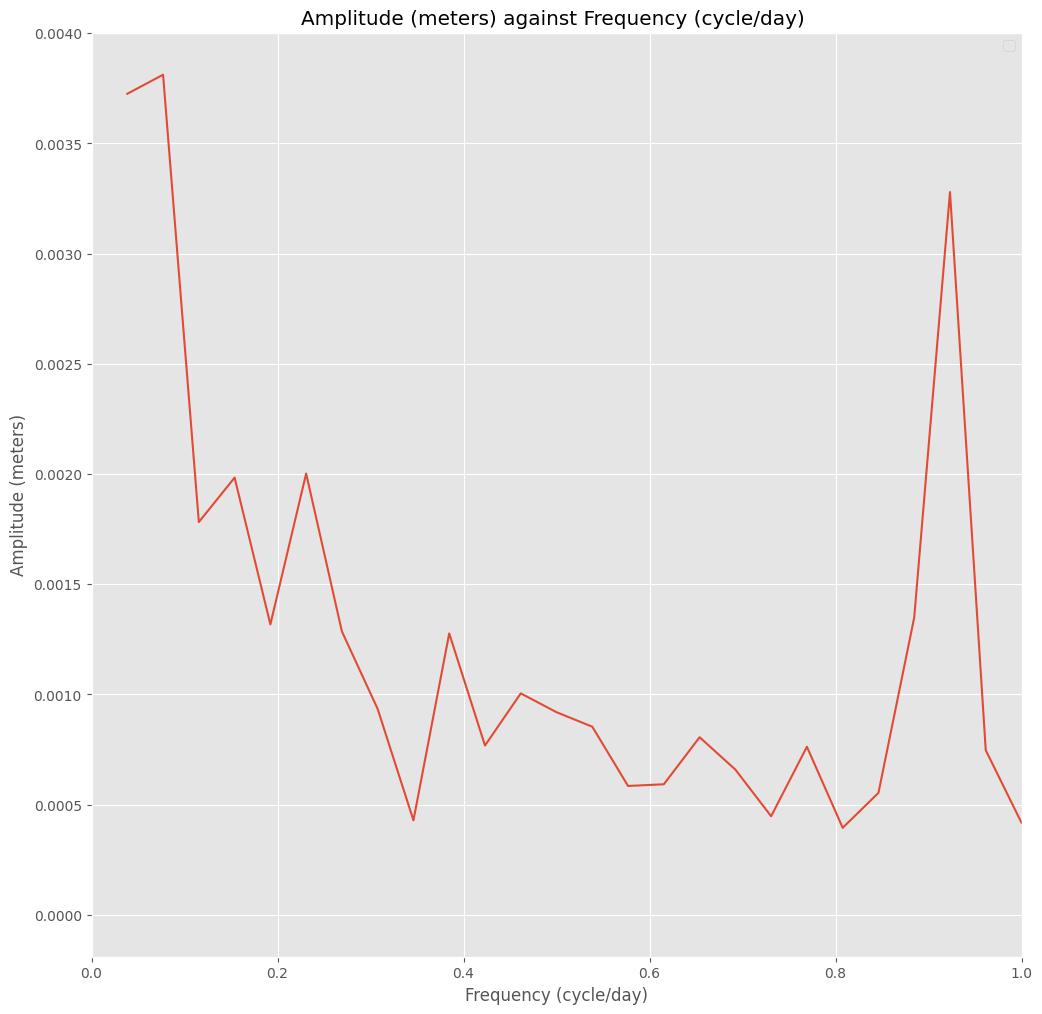

In [96]:
# Make a figure of the power spectrum for flux against frequency
fig = plt.figure(figsize=(12, 12))
ax5 = plt.subplot(111)

# Plot the power against frequency
ax5.plot(freqsfft[1:N//2], np.abs(data_freq_2avg[1:N//2]) / N)
ax5.set_xlim(0,1)
# give title, xlabel, ylabel into axis 
ax5.set_title(f'Amplitude (meters) against Frequency (cycle/day) ')
ax5.set_xlabel(f'Frequency (cycle/day)')
ax5.set_ylabel(f'Amplitude (meters)')

ax5.legend()

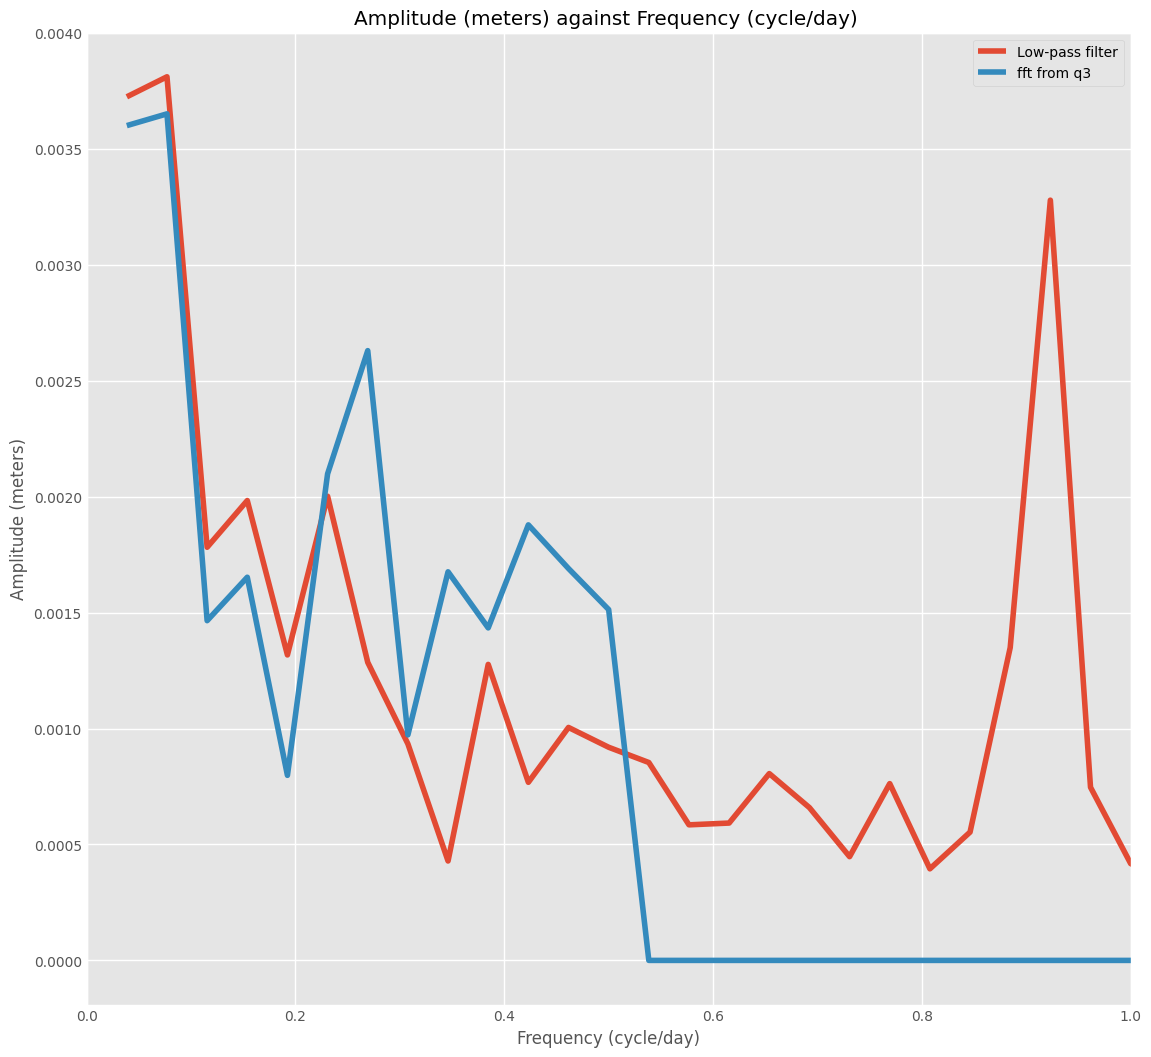

In [123]:
# Make a figure of the power spectrum for flux against frequency
fig = plt.figure(figsize=(12, 12))
ax5 = plt.subplot(111)

# Plot the power against frequency
ax5.plot(freqsfft[1:N//2], np.abs(data_freq_2avg[1:N//2]) / N, label = f"Low-pass filter")
ax5.set_xlim(0,1)
ax5.plot(freqsfft[1:N//2], np.abs(data_freq_1pf[1:N//2]) /N, label = f"fft from q3")
# give title, xlabel, ylabel into axis 
ax5.set_title(f'Amplitude (meters) against Frequency (cycle/day) ')
ax5.set_xlabel(f'Frequency (cycle/day)')
ax5.set_ylabel(f'Amplitude (meters)')

ax5.legend()

#### Describes the differences between this spectrum and that of q3
The first half looks almost similar, but the latter half looks nothing similar. 
This happened because although the data 


### Question 6
In this and next question, we will use two different ways to sub-sampling the data.

In this question, we will sub sample the data that perform running 2-day average on by zeroing out the rows except rows that corresponds to 12 UTC. Then we will multiply the filtered data by 24, so it consistent to question 3, hence we can compare the trend to the one found in question 3.

In [124]:
# print(data_time_2avg)
filter6 = [True] * data_time_2avg.size
for i in range(12,len(data_time_2avg),24):
    filter6[i] = False
# print(filter6)
data_2avg_sub = copy.deepcopy(data_time_2avg)
data_2avg_sub[filter6] = 0
# print(data_2avg_sub[24:48])

[True, True, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, Tr

In [99]:
data_2avg_sub = data_2avg_sub * 24
data_freq_2avg_sub = fft(data_2avg_sub)

Then, we will plot the fft of the subsampled data against time, while limiting the x-axis to a range of 0 to 1.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


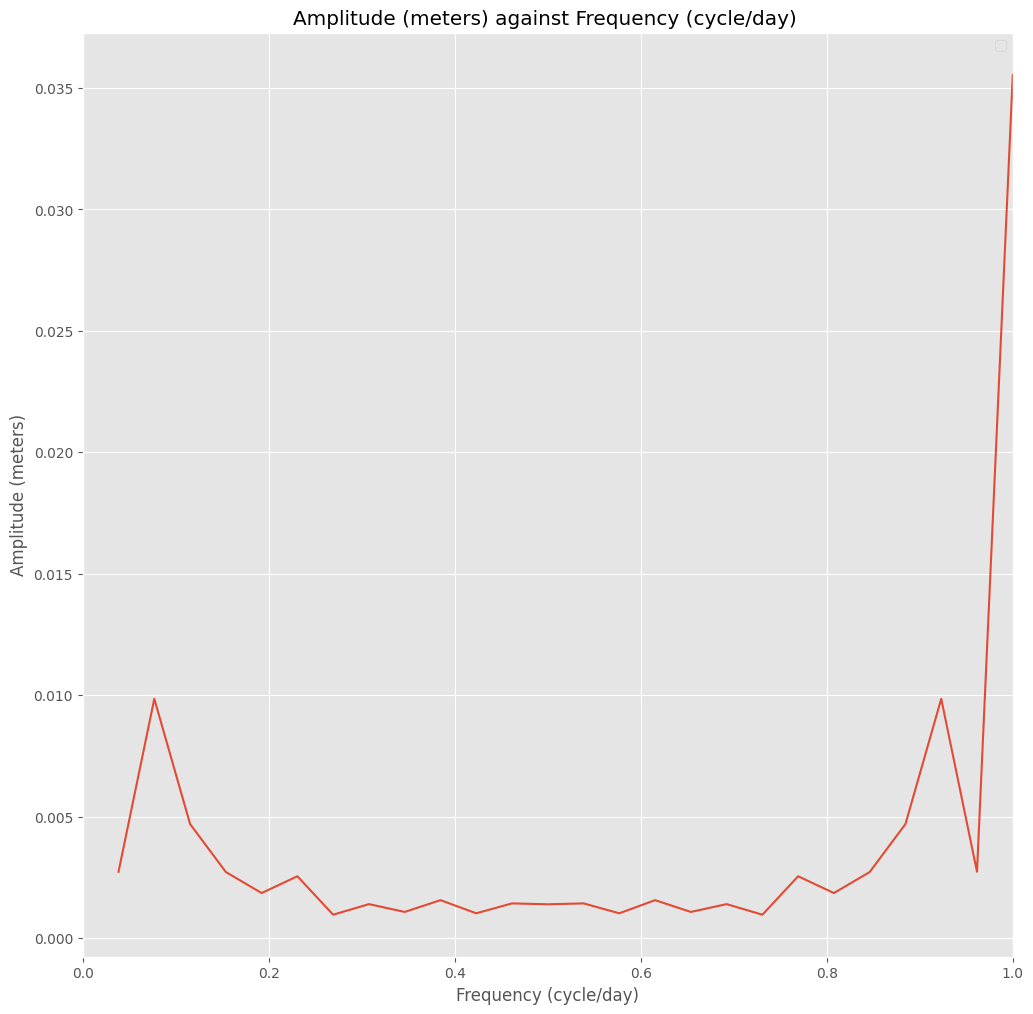

In [100]:
# Make a figure of the power spectrum for flux against frequency
fig = plt.figure(figsize=(12, 12))
ax6 = plt.subplot(111)

# Plot the power against frequency
ax6.plot(freqsfft[1:N//2], np.abs(data_freq_2avg_sub[1:N//2]) / N)
ax6.set_xlim(0,1)
# give title, xlabel, ylabel into axis 
ax6.set_title(f'Amplitude (meters) against Frequency (cycle/day) ')
ax6.set_xlabel(f'Frequency (cycle/day)')
ax6.set_ylabel(f'Amplitude (meters)')

ax6.legend()

After that, we will zeroing out all value that its frequency are higher than 0.5 cycle/day. Then, we perform ifft to bring the filtered frequency domain data into time domain, and plot it against time.

In [101]:
filter = np.abs(freqsfft) > 0.5
data_freq_2pf = copy.deepcopy(data_freq_2avg_sub)
data_freq_2pf[filter] = 0
# print(data_freq_2pf)

In [102]:
data_2avg_sub_lpf = ifft(data_freq_2pf)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


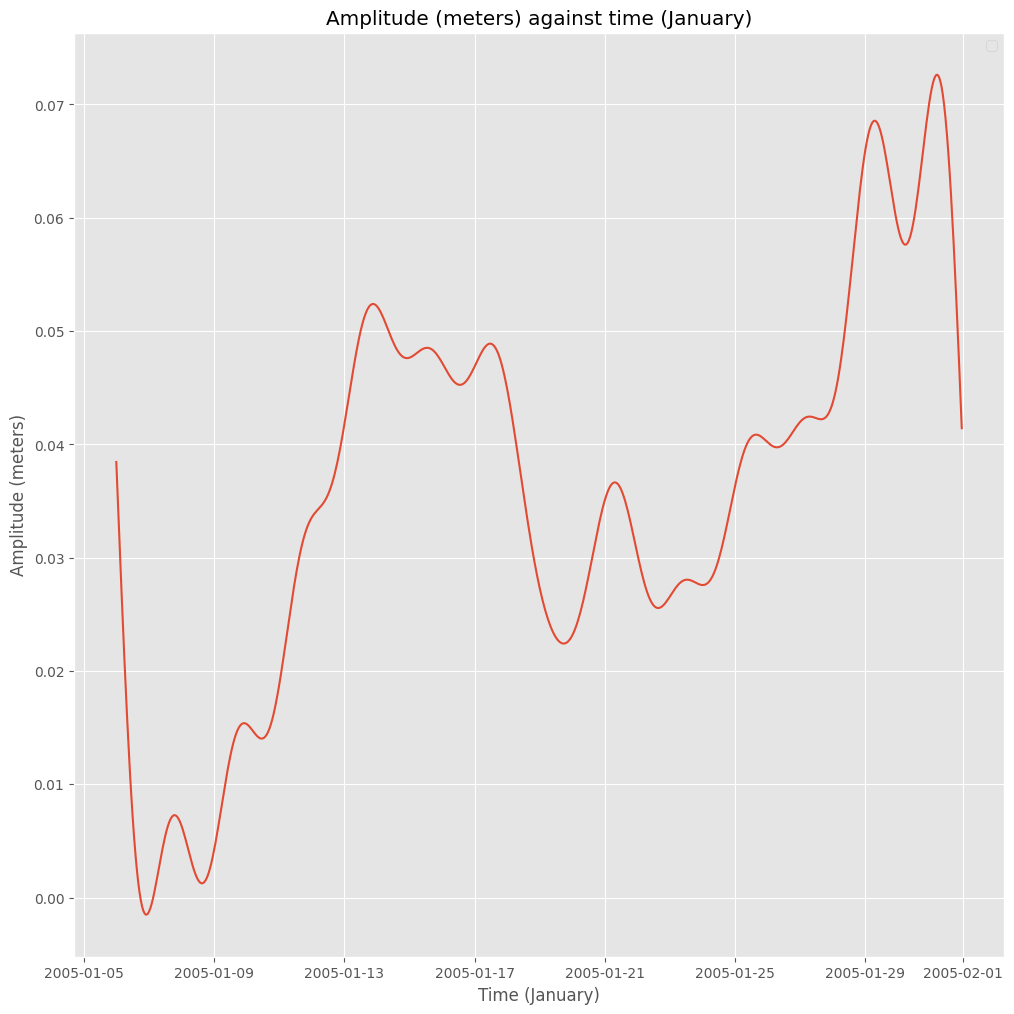

In [103]:
# Make a figure of the power spectrum for flux against frequency
fig = plt.figure(figsize=(12, 12))
ax62 = plt.subplot(111)

# Plot the power against frequency
ax62.plot(times, data_2avg_sub_lpf.real)
# give title, xlabel, ylabel into axis 
ax62.set_title(f'Amplitude (meters) against time (January)')
ax62.set_xlabel(f'Time (January)')
ax62.set_ylabel(f'Amplitude (meters)')

ax62.legend()

#### What trend if any can you see in the sea level estimated from latest variable over the course of Jan2005

#### How does this trend compared to the "gold standard"


#### Is the latest variable Nyquist sampled or not, Discuss reasoning

### Question 7
In this last question, instead of sub-sampling the running 2-days average data like we did in question 6, we will sub-sampling the whole data. Hence, the below code is similar to the above, except the variable used.

In [104]:
# print(data_time_2avg)
filter7 = [True] * heights.size
for i in range(12,len(heights),24):
    filter7[i] = False
# print(filter6)
data_sub = copy.deepcopy(heights)
data_sub[filter7] = 0
# print(data_2avg_sub[24:48])

In [105]:
data_sub = data_sub * 24
data_freq_sub = fft(data_sub)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


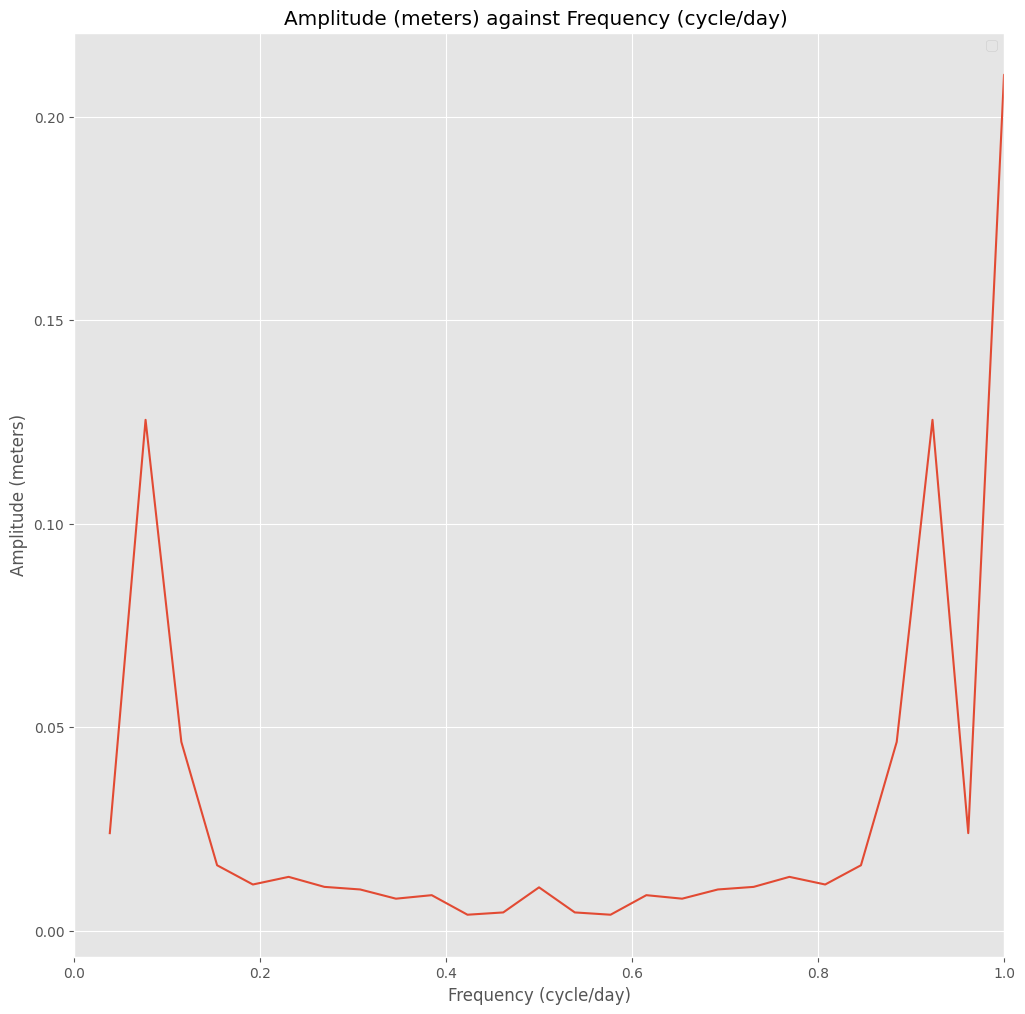

In [106]:
# Make a figure of the power spectrum for flux against frequency
fig = plt.figure(figsize=(12, 12))
ax7 = plt.subplot(111)

# Plot the power against frequency
ax7.plot(freqsfft[1:N//2], np.abs(data_freq_sub[1:N//2]) / N)
ax7.set_xlim(0,1)
# give title, xlabel, ylabel into axis 
ax7.set_title(f'Amplitude (meters) against Frequency (cycle/day) ')
ax7.set_xlabel(f'Frequency (cycle/day)')
ax7.set_ylabel(f'Amplitude (meters)')

ax7.legend()

In [107]:
filter = np.abs(freqsfft) > 0.5
data_sub_lpf = copy.deepcopy(data_freq_sub)
data_sub_lpf[filter] = 0
# print(data_sub_1pf)
data_sub_lpf = ifft(data_sub_lpf)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


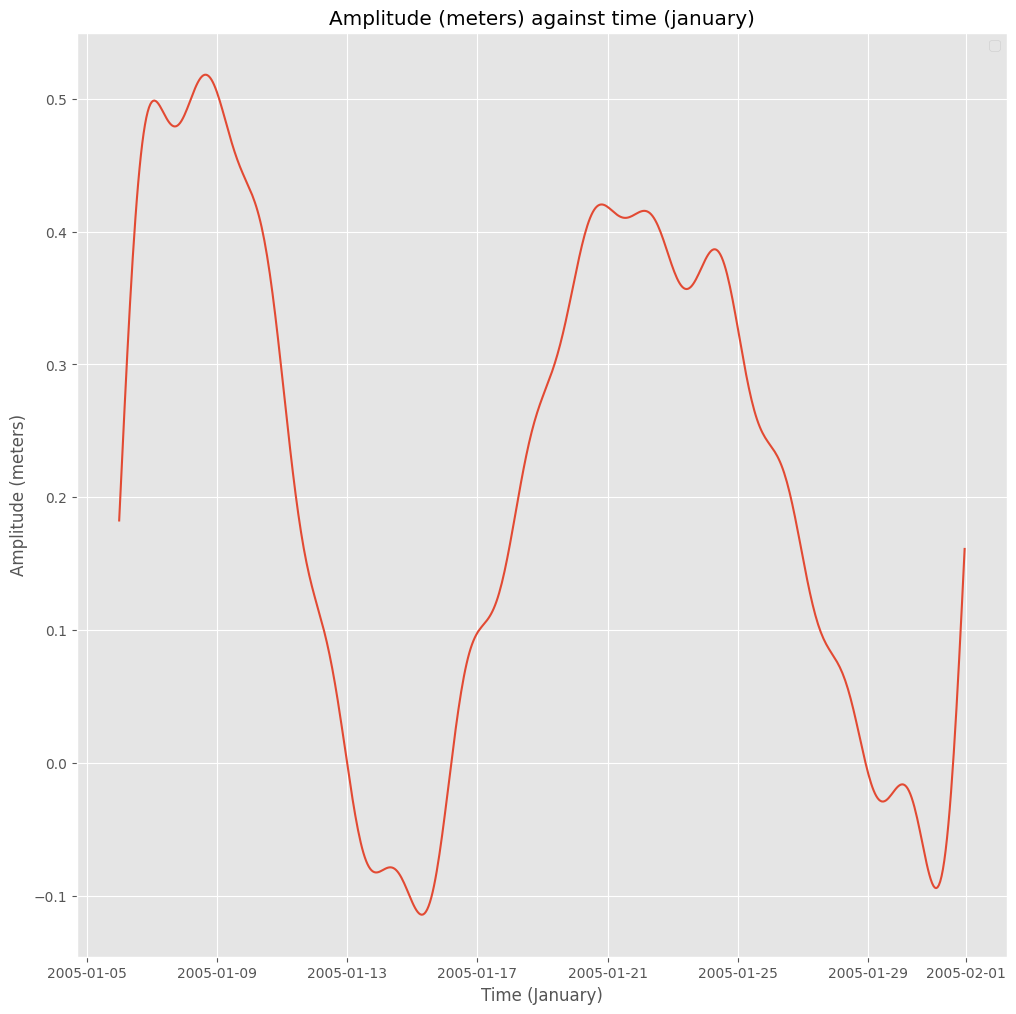

In [108]:
# Make a figure of the power spectrum for flux against frequency
fig = plt.figure(figsize=(12, 12))
ax72 = plt.subplot(111)
# print(data_sub_1pf.real.size)
# print(freqsfft[1:N//2].size)
# Plot the power against frequency
ax72.plot(times, data_sub_lpf.real)
# give title, xlabel, ylabel into axis 
ax72.set_title(f'Amplitude (meters) against time (january)')
ax72.set_xlabel(f'Time (January)')
ax72.set_ylabel(f'Amplitude (meters)')

ax72.legend()

#### What trend if any can you see in the sea level estimated from latest variable over the course of Jan2005

#### How does this trend compared to the "gold standard" and data_2avg_sub_lpf from q6


#### Is the latest variable Nyquist sampled or not, Discuss reasoning

## Conclusions





## References
List any references used